In [1]:
import pandas as pd

url = "https://github.com/ginozevallosmonjaras/PA1-Machine-Learning/raw/refs/heads/main/diabetes.csv"

df = pd.read_csv(url)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df.shape

(768, 9)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


In [9]:
df["Outcome"].value_counts(normalize=True) * 100

,proportion
Outcome,
0,65.104167
1,34.895833


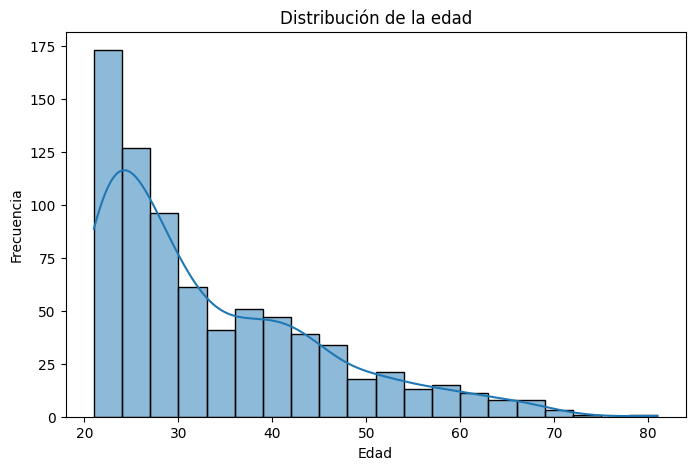

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Age", bins=20, kde=True)

plt.title("Distribución de la edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

### Interpretacion de la grafica 1

La grafica muestra la distribucion de las edades de las personas del
dataset, se ve una mayor concentracion de personas entre los 20 y
30 años aproximadamente, la distribucion muestra mayores datos concentracion en edades mas jovenes.

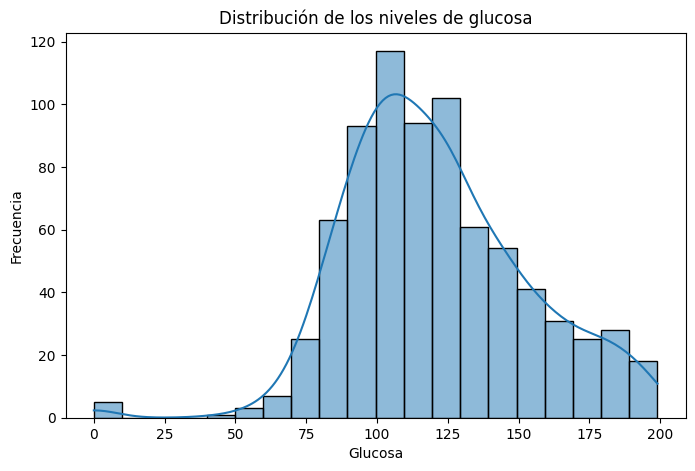

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Glucose", bins=20, kde=True)

plt.title("Distribución de los niveles de glucosa")
plt.xlabel("Glucosa")
plt.ylabel("Frecuencia")

plt.show()

### Interpretacion del grafico 2

Se ve una distribucion de los niveles de glucosa en referencia a las personas del dataset, se ve que la mayor cantidad de registros esta entre los 90 y 140, tambine se puede ver que unos llegan incluso hasta los 150 a 200.

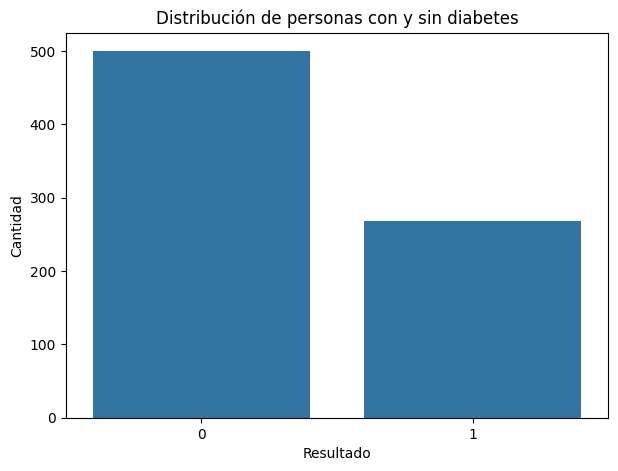

In [12]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Outcome")

plt.title("Distribución de personas con y sin diabetes")
plt.xlabel("Resultado")
plt.ylabel("Cantidad")

plt.show()

### Interpretación de la gráfica 3

Se puede ver la cantidad de personas, segun el resultado de la variable outcome, las personas en que figuran en la columna 0, son las que no tienen diabetes y las de la columna 1, tienen diabetes, la mayoria esta en la columna 0, no tienen diabetes.

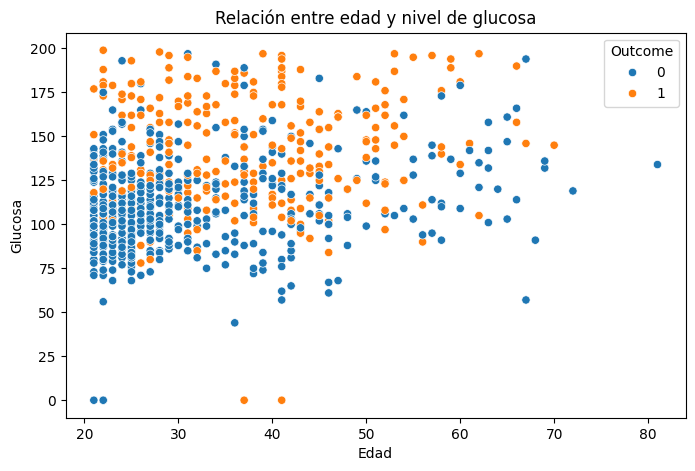

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Glucose",
    hue="Outcome"
)

plt.title("Relación entre edad y nivel de glucosa")
plt.xlabel("Edad")
plt.ylabel("Glucosa")

plt.show()

### Interpretacion de la grafica 4

Se muestra la relacion entre la edad y el nivel de glucosa, se puede ver que los registros de ambas categorias aparecen en diferentes edades y niveles de glucosa.

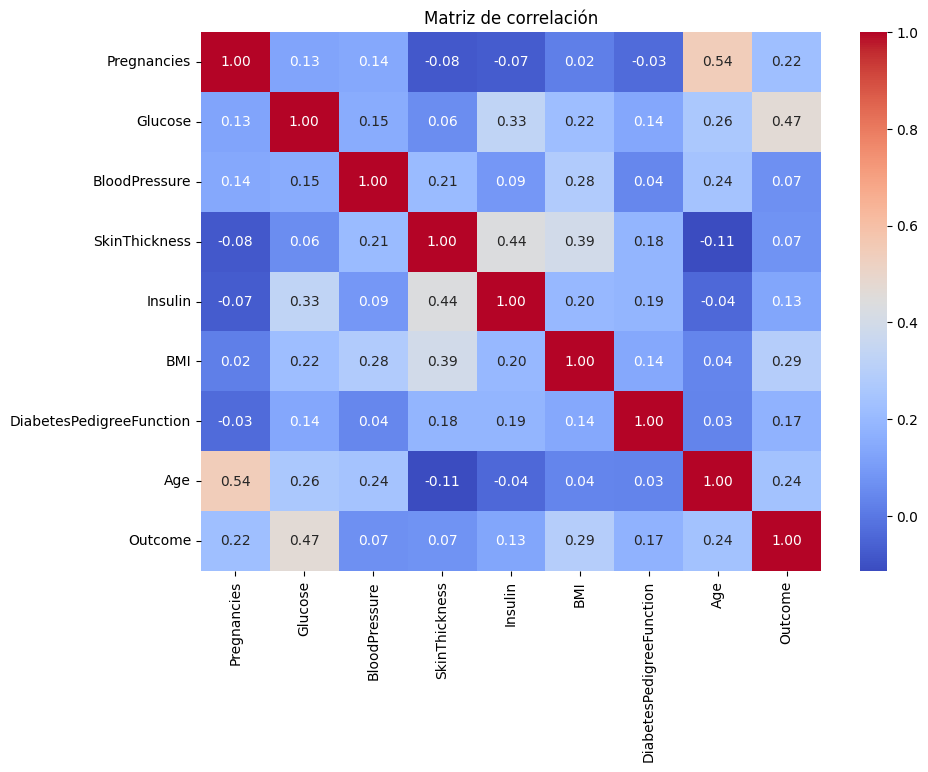

In [14]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación")

plt.show()

### Interpretacion del grafico

La matriz de correlación permite observar la relacion entre las variables del dataset, se observa que Glucose presenta la mayor correlacion con Outcome, con un valor aproximado de 0.47.

In [15]:
df_procesado = df.copy()

df_procesado.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [16]:
columnas = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

(df_procesado[columnas] == 0).sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [17]:
import numpy as np

columnas = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df_procesado[columnas] = df_procesado[columnas].replace(0, np.nan)

df_procesado.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [18]:
for columna in columnas:
    df_procesado[columna] = df_procesado[columna].fillna(
        df_procesado[columna].median()
    )

df_procesado.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [19]:
X = df_procesado.drop("Outcome", axis=1)

y = df_procesado["Outcome"]

print("Características (X):")
print(X.head())

print("\nVariable objetivo (y):")
print(y.head())

Características (X):
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Variable objetivo (y):
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (614, 8)
Datos de prueba: (154, 8)


In [22]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000)

modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [23]:
y_pred = modelo.predict(X_test)

print("Predicciones:")
print(y_pred[:20])

Predicciones:
[1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0]


In [24]:
print("Valores reales:")
print(y_test.values[:20])

Valores reales:
[0 0 0 1 0 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0]


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Accuracy: 0.7013
Precision: 0.587
Recall: 0.5
F1 Score: 0.54


### Evaluacion del modelo

El modelo de regresion logistica obtuvo un accuracy de 70.13%, quiere
decir que de cada 100 casos aproximadamente 70 fueron clasificados de forma correcta

La precision fue de 58.70%, lo que significa que cuando el modelo dijo que
una persona tenia diabetes, en varios casos esa prediccion fue correcta.

El recall fue de 50%, esto quiere decir que el modelo logro identificar
correctamente la mitad de los casos que realmente tenian diabetes.

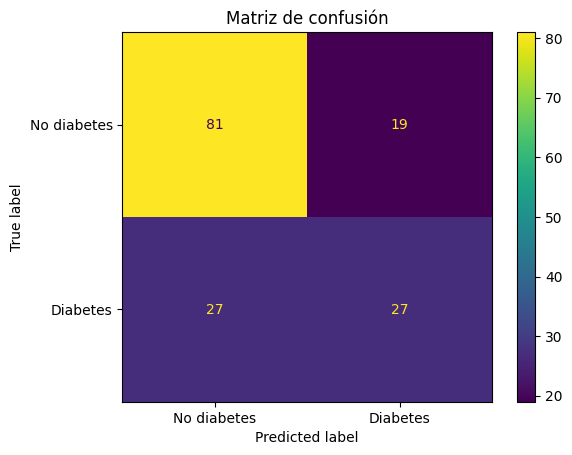

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No diabetes", "Diabetes"]
)

disp.plot()

plt.title("Matriz de confusión")
plt.show()

### Interpretacion de la matriz de confusion

La matriz de confusion nos da los resultados de las predicciones de forma mas detallada, el modelo acerto 81 casos de personas que no tenian diabetes y 27 casos de personas que si tenian diabetes.

Tambien tuvo 19 casos en los que predijo diabetes cuando el resultado
real era no diabetes y 27 casos en los que predijo no diabetes cuando el
resultado real era diabetes.

In [27]:
import joblib

joblib.dump(modelo, "modelo_diabetes.pkl")

print("Modelo guardado correctamente")

Modelo guardado correctamente
